In [1]:
!git clone --recursive https://github.com/bemc22/GeneralizedR2R
%cd GeneralizedR2R
!pip install ./deepinv/

Cloning into 'GeneralizedR2R'...
remote: Enumerating objects: 513, done.
remote: Counting objects: 100% (276/276), done.
remote: Compressing objects: 100% (179/179), done.
remote: Total 513 (delta 153), reused 105 (delta 97), pack-reused 237 (from 1)
Receiving objects: 100% (513/513), 74.31 MiB | 27.32 MiB/s, done.
Resolving deltas: 100% (240/240), done.
Submodule 'deepinv' (https://github.com/deepinv/deepinv) registered for path 'deepinv'
Cloning into '/content/GeneralizedR2R/deepinv'...
remote: Enumerating objects: 29673, done.        
remote: Counting objects: 100% (313/313), done.        
remote: Compressing objects: 100% (248/248), done.        
remote: Total 29673 (delta 207), reused 65 (delta 65), pack-reused 29360 (from 4)        
Receiving objects: 100% (29673/29673), 213.86 MiB | 29.87 MiB/s, done.
Resolving deltas: 100% (22133/22133), done.
Submodule path 'deepinv': checked out 'cd46448536b5ba18b88ffe40dbecf9b1aaaa6ada'
/content/GeneralizedR2R
Processing ./deepinv
  Installi

In [2]:
r"""
Self-supervised learning with Generalized Recorrupted-to-Recovered (GR2R)
====================================================================================================

This example shows you how to train a reconstruction network for an denoising problem on a fully self-supervised way, i.e., using corrupted measurement data only.
"""

import os
import deepinv as dinv
from torch.utils.data import DataLoader
import torchvision
import torch
from pathlib import Path
from torchvision import transforms
from deepinv.optim.prior import PnP
from deepinv.utils.demo import load_dataset, load_degradation
import wandb
import argparse
from torch.utils.data import DataLoader, random_split
from deepinv.loss import PSNR, SSIM, Loss, SupLoss

from deepinv.training import train

In [3]:
class Args:
    batch_size  = 50
    loss        = "gr2r_mse"
    epochs      = 800
    lr          = 1e-4
    noise       = None
    trial       = 0
    alpha       = 0.2

args = Args()

In [4]:
noise_distribution = 'gaussian' # @param ["gaussian", "poisson", "gamma"]

if noise_distribution == "gaussian":
    args.noise     = 0.1
    noise_model    = dinv.physics.GaussianNoise(args.noise)

elif noise_distribution == "poisson":
    args.noise     = 0.1
    noise_model    = dinv.physics.PoissonNoise(args.noise)
    noise_model.sigma = args.noise

elif noise_distribution == "gamma":
    args.noise     = 5.0
    noise_model    = dinv.physics.GammaNoise(args.noise)
    noise_model.sigma = args.noise

r2r_loss = dinv.loss.R2RLoss(noise_model=noise_model, alpha=args.alpha)
# print actual setup
print("Selecting noise model: ", noise_distribution)
print("Noise level: ", args.noise)
print("Alpha: ", args.alpha)

Selecting noise model:  gaussian
Noise level:  0.1
Alpha:  0.2


In [5]:
# ---------------------------------------------------------------
# Setup paths for data loading and results.
# ---------------------------------------------------------------

BASE_DIR = Path(".")
# PROJECT_NAME = "denoising-poisson"
PROJECT_NAME = f"denoising-{noise_distribution}"
ORIGINAL_DATA_DIR =  Path("./data")
DATA_DIR = ORIGINAL_DATA_DIR / "measurements"
RESULTS_DIR = BASE_DIR / "results"
DEG_DIR = BASE_DIR / "degradations"
CKPT_DIR = BASE_DIR / "ckpts" / PROJECT_NAME
verbose   = True
wandb_vis = False

# Set the global random seed from pytorch to ensure reproducibility of the example.
device = dinv.utils.get_freer_gpu() if torch.cuda.is_available() else "cpu"

Selected GPU 0 with 14910 MiB free memory 


In [6]:
# print  all the arguments
trial_id = args.trial
torch.manual_seed(trial_id)

run_name = f"{args.loss}-{args.noise}"

wandb_setup = {
    "project": PROJECT_NAME,
    "config": args,
    "name": run_name,
}

In [7]:
# # ----------------------------------------------------------------------------------
# Generate a dataset of knee images and load it.
# ----------------------------------------------------------------------------------
from deepinv.datasets import SimpleFastMRISliceDataset
from deepinv.utils.demo import get_data_home

# defined physics
physics = dinv.physics.Denoising(noise_model=noise_model)

# Use parallel dataloader if using a GPU to fasten training,
# otherwise, as all computes are on CPU, use synchronous data loading.
num_workers     = 0 if torch.cuda.is_available() else 0
n_images_max    = 900 # if is greater that train set, image may will duplicated

my_dataset_name = "mri_gaussian_denoising"
operation = f"Denoising_{args.noise}"
train_dataset_name = f"fastmri_knee_singlecoil"
measurement_dir = DATA_DIR / train_dataset_name / operation

# check if the dataset is already generated
# if not, generate it


img_size = 256
# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.RandomCrop((img_size, img_size))
#     ])

# test_transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.CenterCrop((img_size, img_size))
# ])
transform = transforms.Compose([transforms.Resize(img_size)])

# div2k_train_path    = ORIGINAL_DATA_DIR / "DIV2K_train_HR.zip"
# div2k_test_path     = ORIGINAL_DATA_DIR / "DIV2K_valid_HR.zip"

download_train  = True # !os.path.exists(div2k_train_path)
download_test   = True # !os.path.exists(div2k_test_path)

# train_dataset    =  dinv.datasets.DIV2K(root=ORIGINAL_DATA_DIR, mode="train", transform=transform, download=download_train)
# test_dataset     =  dinv.datasets.DIV2K(root=ORIGINAL_DATA_DIR, mode="val", transform=test_transform, download=download_test)

train_dataset = SimpleFastMRISliceDataset(
    get_data_home(), transform=transform, train_percent=0.5, train=True, download=True
)

test_dataset = SimpleFastMRISliceDataset(
    get_data_home(), transform=transform, train_percent=0.5, train=False
)


if not os.path.exists(measurement_dir / f"{my_dataset_name}0.h5"):
    deepinv_datasets_path = dinv.datasets.generate_dataset(
        train_dataset=train_dataset,
        test_dataset=test_dataset,
        physics=physics,
        device=device,
        save_dir=measurement_dir,
        train_datapoints=n_images_max,
        num_workers=num_workers,
        dataset_filename=str(my_dataset_name),
    )
else:
    deepinv_datasets_path = measurement_dir / f"{my_dataset_name}0.h5"

train_dataset = dinv.datasets.HDF5Dataset(path=deepinv_datasets_path, train=True)
test_dataset = dinv.datasets.HDF5Dataset(path=deepinv_datasets_path, train=False)

  0%|          | 0/820529 [00:00<?, ?it/s]

Dataset has been saved at data/measurements/fastmri_knee_singlecoil/Denoising_0.1/mri_gaussian_denoising0.h5


In [8]:
# Set up the reconstruction network
# ---------------------------------------------------------------

n_channels = 2

# model = dinv.models.ArtifactRemoval( dinv.models.DRUNet( in_channels=n_channels,
#                             out_channels=n_channels,
#                             pretrained=None,
#                             nc=[16, 32, 64, 128]
#                             ).to(device)
# )

model = dinv.models.ArtifactRemoval( dinv.models.DnCNN(
                                in_channels=n_channels,
                                 out_channels=n_channels,
                                 pretrained=None,
                                 depth=7,
                                 ).to(device)
)

# print number of parameters
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")


# Set up the training parameters
# --------------------------------------------

epochs        = args.epochs
learning_rate = args.lr
batch_size    = args.batch_size # if torch.cuda.is_available() else 1
noise_level   = args.noise


if args.loss == "sup":   # SUPERVISED LOSS
    loss = dinv.loss.SupLoss()

elif args.loss == "gr2r_mse": # GENERALIZED R2R LOSS - MSE VARIANT
    loss     = [ r2r_loss ]
    # model    = r2r_loss.adapt_model(model)

elif args.loss == "neigh": # NEIGHBORHOOD LOSS

    neigh_loss = dinv.loss.Neighbor2Neighbor()
    loss = [ neigh_loss ]


optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=int(epochs * 0.8) + 1)


Number of parameters: 187010


In [1]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True
)
test_dataloader = DataLoader(
    test_dataset, batch_size=1, num_workers=num_workers, shuffle=False
)

trainer = dinv.Trainer(
    metrics=[ PSNR(), SSIM() ],
    model=model,
    physics=physics,
    epochs=epochs,
    scheduler=scheduler,
    losses=loss,
    optimizer=optimizer,
    train_dataloader=train_dataloader,
    plot_images=True,
    device=device,
    save_path=Path(CKPT_DIR / f"noise={args.noise}"  / args.loss ),
    verbose=verbose,
    wandb_vis=False,
    show_progress_bar=False,
    ckp_interval=1,
    wandb_setup=None,
    eval_dataloader=test_dataloader,
    freq_plot=200,
)

model = trainer.train()

NameError: name 'train_dataset' is not defined

EVALUATING THE MODEL ON THE TEST DATASET
Eval epoch 0: PSNR=35.358, PSNR no learning=20.005, SSIM=0.902, SSIM no learning=0.126


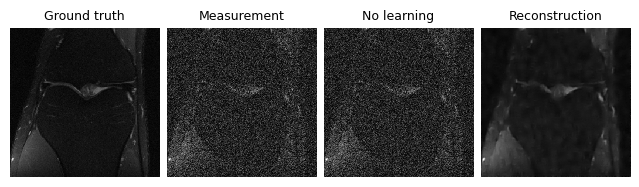

Test results:
PSNR no learning: 20.005 +- 0.020
PSNR: 35.358 +- 1.176
SSIM no learning: 0.126 +- 0.019
SSIM: 0.902 +- 0.027


{'PSNR no learning': 20.004791703942704,
 'PSNR no learning_std': 0.020400981937728928,
 'PSNR': 35.358095926781225,
 'PSNR_std': 1.176101990920144,
 'SSIM no learning': 0.1258647429616484,
 'SSIM no learning_std': 0.019475929126825744,
 'SSIM': 0.9016822723493184,
 'SSIM_std': 0.026844649372037167}

In [ ]:
# Evaluate the model on the test dataset
print("EVALUATING THE MODEL ON THE TEST DATASET")
trainer.freq_plot = 1
trainer.test(test_dataloader)

In [1]:
import os
import torchvision.utils
import torch

# Create a directory to save the training images
output_dir = "training_ground_truth_images_png"
os.makedirs(output_dir, exist_ok=True)

print(f"Saving training ground truth images to '{output_dir}'...")

# Iterate through the training dataset and save images
# Assuming `train_dataset` yields (ground_truth_image, measurement, physics)
for i, sample in enumerate(train_dataset):
    ground_truth_image = sample[0] # Extract the ground truth image

    # If the image has 2 channels (e.g., complex numbers), convert to magnitude
    if ground_truth_image.shape[0] == 2:
        # Assuming channels are real and imaginary parts, calculate magnitude
        ground_truth_image = torch.sqrt(ground_truth_image[0]**2 + ground_truth_image[1]**2).unsqueeze(0)

    # Normalize image to 0-1 range for proper saving if not already
    min_val = ground_truth_image.min()
    max_val = ground_truth_image.max()
    if max_val - min_val > 1e-6: # Avoid division by zero for constant images
        ground_truth_image = (ground_truth_image - min_val) / (max_val - min_val)

    # Save the image as PNG
    image_path = os.path.join(output_dir, f"train_ground_truth_{i:04d}.png")
    torchvision.utils.save_image(ground_truth_image, image_path)

    if i >= 99: # Save first 100 images as an example
        print(f"Saved {i+1} training ground truth images as examples.")
        break

    if i == len(train_dataset) - 1: # If loop completes without breaking
        print(f"Saved all {len(train_dataset)} training ground truth images.")


Saving training ground truth images to 'training_ground_truth_images_png'...


NameError: name 'train_dataset' is not defined